# Feature Usefulness experimentation

In this notebook we will compute the usefulness score for the features of decision trees working on the California Housing Dataset. We will only consider decision trees.

### Code to create decision trees

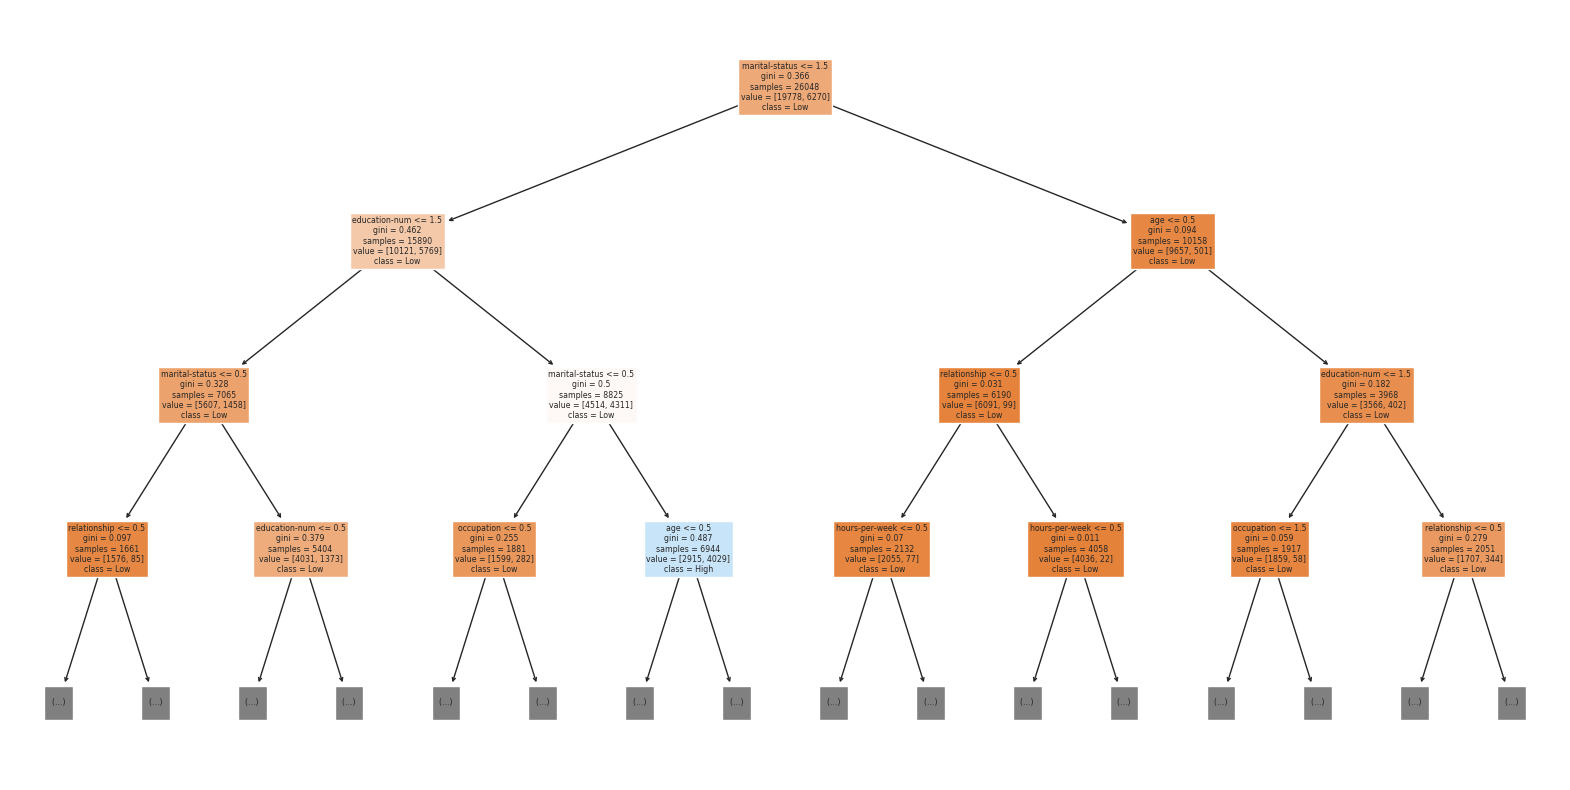

In [61]:
import math
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import random
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer, OrdinalEncoder
import warnings

## Train a tree for the California Housing Dataset
def train_tree_for_California(max_depth, seed, bins, random_state, leaves=1000000):
    housing = fetch_california_housing(as_frame=True)
    X = housing.data
    y = housing.target

    # We booleanize the prediction by taking the median as a threshold
    median_value = np.median(y)
    y_binary = (y > median_value).astype(int)

    # We make all other features categorical
    kbins = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile')
    X_binned = kbins.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_binned, y_binary, test_size=0.2, random_state=seed)

    # Train a Decision Tree classifier
    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth, max_leaf_nodes=leaves)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return clf, accuracy, X.columns

## Train a tree for the Adult Income Dataset
def train_tree_for_Adult_Income(max_depth, seed, bins, random_state, leaves=100000):
    column_names = [
        "age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
    ]
    
    df = adult_income_dataset
    X = df.drop("income", axis=1)
    y = df["income"]
    
    # Step 3: Encode categorical columns to ordinal integers
    cat_cols = X.select_dtypes(include="object").columns
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    
    # Encode categorical features as ordinal integers
    encoder = OrdinalEncoder()
    X[cat_cols] = encoder.fit_transform(X[cat_cols])
    
    # Step 4: Discretize *all* features into categorical bins
    # We'll use 5 bins, and encode as ordinal integers (like categories)
    kbins = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile')
    warnings.simplefilter("ignore")
    X_binned = kbins.fit_transform(X)
    
    # Step 5: Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_binned, y, test_size=0.2, random_state=seed)
    
    # Step 6: Train a Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth, max_leaf_nodes=leaves)
    clf.fit(X_train, y_train)
    
    # Step 7: Evaluate
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return clf, acc, column_names

# Download the adult income dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult_income_dataset = pd.read_csv(url, names=column_names, na_values=" ?", skipinitialspace=True)

clf, _, features = train_tree_for_Adult_Income(4, 42, 3, 42)
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=features, class_names=["Low", "High"], filled=True, max_depth=3)
plt.show()

### Code to compute the usefullness score

In [65]:
## Class to represent nodes of the decision trees
class Node:
    feature = None
    threshold = None
    left = None
    right = None

    def __init__(self, feature, threshold, left, right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

    def get_feature(self):
        return self.feature

    def set_feature(self, new_feature):
        old_feature = self.feature
        self.feature = new_feature
        return old_feature

    def get_threshold(self):
        return self.threshold

    def set_threshold(self, new_threshold):
        old_threshold = self.threshold
        self.threshold = new_threshold
        return old_threshold

    def get_left(self):
        return self.left

    def set_left(self, node):
        self.left = node

    def get_right(self):
        return self.right

    def set_right(self, node):
        self.right = node

    def is_leaf(self):
        return self.left == None

    def is_true(self):
        return self.feature == "True"

    def is_false(self):
        return not self.is_true()

## Internal representation of decision trees
class Tree:
    root = None
    domains = None

    def __init__(self, root, domains):
        self.root = root
        self.domains = domains

    def get_root(self):
        return self.root

    def _count_recursive(self, node, ranges):
        if node.is_leaf() and node.is_true():
            fail = False
            acum = 1
            for (a, b) in ranges.values():
                if b < a:
                    return 0
                acum = acum * (math.floor(b) - math.ceil(a) + 1)
            #print(ranges)
            #print(acum)
            if acum < 0:
                print(ranges)
            return acum

        elif not node.is_leaf():
            acum = 0
            
            cur_feature = node.get_feature()
            cur_threshold = node.get_threshold()

            a, b = ranges[cur_feature]

            ranges[cur_feature] = (a, min(cur_threshold, b))
            acum += 0 if min(cur_threshold, b) < a else self._count_recursive(node.get_left(), ranges)

            ranges[cur_feature] = (max(cur_threshold + (math.ceil(cur_threshold) - cur_threshold) / 2, a), b)
            acum += 0 if b < max(cur_threshold + (math.ceil(cur_threshold) - cur_threshold) / 2, a) else self._count_recursive(node.get_right(), ranges)

            ranges[cur_feature] = (a, b)
            return acum

        else:
            return 0
                
    
    def count(self):
        ranges = {feature: self.domains[feature] for feature in self.domains.keys()}
        
        return self._count_recursive(self.root, ranges)

    def _negate_recursive(self, node):
        if node.is_leaf():
            if node.get_feature() == "True":
                node.set_feature("False")
            else:
                node.set_feature("True")

        else:
            self._negate_recursive(node.get_left())
            self._negate_recursive(node.get_right())
    
    def negate(self):
        return self._negate_recursive(self.root)

    def _conjunction_recursive(self, node, prev_node, other_tree):
        if node.is_leaf():
            if node.is_true():
                if prev_node.get_right() == node:
                    prev_node.set_right(other_tree.get_root())
                else:
                    prev_node.set_left(other_tree.get_root())
        else:
            self._conjunction_recursive(node.get_left(), node, other_tree)
            self._conjunction_recursive(node.get_right(), node, other_tree)

    # Never use more than once in the same tree: we store references instead of copies to avoid using quadratic memory.
    def conjunction(self, other_tree):
        return self._conjunction_recursive(self.root, None, other_tree)

    def _condition_recursive(self, node, feature, value):
        if node.is_leaf():
            return
        else:
            if node.get_feature() == feature:
                if value <= node.get_threshold():
                    node.set_threshold(1e9)
                else:
                    node.set_threshold(-1)

            self._condition_recursive(node.get_left(), feature, value)
            self._condition_recursive(node.get_right(), feature, value)
                
    
    def condition(self, feature, value):
        self._condition_recursive(self.root, feature, value)
    
    def _print_recursive(self, node, tabs):
        if node == None:
            return
        else:
            space = " " * tabs
            print(f'{space}{node.get_feature()} (<= {node.get_threshold()})')
            self._print_recursive(node.get_left(), tabs+3)
            self._print_recursive(node.get_right(), tabs+3)
            
    def print(self):
        self._print_recursive(self.root, 0)

def dec_tree_to_my_tree_rec(node, dec_tree, features):
    if dec_tree.tree_.feature[node] != -2:  # Not a leaf
        feature_name = features[dec_tree.tree_.feature[node]]
        left_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_left[node], dec_tree, features)
        right_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_right[node], dec_tree, features)
        threshold = clf.tree_.threshold[node]
        return Node(feature_name, threshold, left_node, right_node)
    else:
        value = dec_tree.tree_.value[node]
        predicted_class = np.argmax(value)
        if predicted_class == 1:
            return Node("True", 1, None, None)
        else:
            return Node("False", 0, None, None)

## Code to translate SKlearn trees to ours
def dec_tree_to_my_tree(dec_tree, domains, features):
    root = dec_tree_to_my_tree_rec(0, dec_tree, features)
    return Tree(root, domains)

## Code to compute scores
def compute_score(tree, feature, num_features, domains):
    tree_0 = deepcopy(tree)
    tree_0.condition(feature, 0)
    for val in range(domains[feature][0]+1, domains[feature][1] + 1):
        tree_next = deepcopy(tree)
        tree_next.condition(feature, val)
        tree_next.conjunction(tree_0)
        tree_0 = tree_next
        #tree_0.print()

    acum = tree_0.count()

    negated_tree_0 = deepcopy(tree)
    negated_tree_0.negate()
    negated_tree_0.condition(feature, 0)
    for val in range(domains[feature][0]+1, domains[feature][1] + 1):
        tree_next = deepcopy(tree)
        tree_next.condition(feature, val)
        tree_next.negate()
        tree_next.conjunction(negated_tree_0)
        negated_tree_0 = tree_next

    acum += negated_tree_0.count()

    total = 1
    for feature in features:
        a, b = domains[feature]
        total *= (math.floor(b) - math.ceil(a) + 1)
    
    return total - acum

### Computing the scores
#### California Housing Dataset

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.8274588178294575


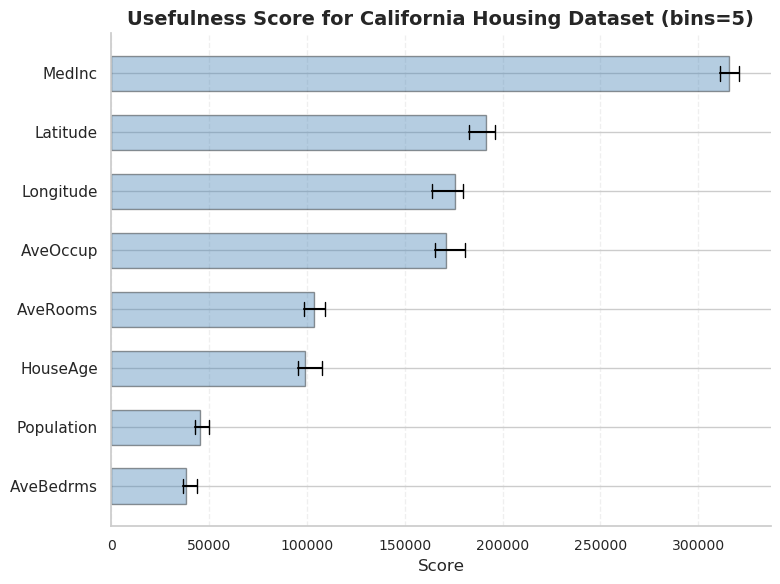

<Figure size 640x480 with 0 Axes>

In [69]:
random.seed(42)

bins = 5
tries = 20

_, _, features = train_tree_for_California(2, 42, 3, 42)

scores = {feature: [] for feature in features}
accuracies = []

for i in range(tries):
    random_value = random.randint(0, 100000)
    clf, accuracy, features = train_tree_for_California(100000, random_value, bins, random_value, 100*bins)
    
    domains = {feature: (0, bins-1) for feature in features}
    tree = dec_tree_to_my_tree(clf, domains, features)
    
    for feature in features:
        scores[feature].append(compute_score(tree, feature, len(features), domains))
    accuracies.append(accuracy)
    print(i)

stats = []
for k, v in scores.items():
    q1 = np.percentile(v, 25)
    med = np.median(v)
    q3 = np.percentile(v, 75)
    stats.append((k, q1, med, q3))

# Sort by median
stats.sort(key=lambda x: x[2])
labels, q1s, meds, q3s = zip(*stats)
y_pos = np.arange(len(labels))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Main horizontal bars at median
ax.barh(y_pos, meds, color='steelblue', alpha=0.4, edgecolor='black', height=0.6)

bar_height = 0.6
line_height = bar_height * 0.4  # 40% of full bar height
for y, q1, q3 in zip(y_pos, q1s, q3s):
    # Short horizontal line for Q1–Q3
    ax.plot([q1, q3], [y, y], color='black', linewidth=1.5)

    # Small vertical ticks at Q1 and Q3
    ax.plot([q1, q1], [y - line_height / 2, y + line_height / 2], color='black', linewidth=1)
    ax.plot([q3, q3], [y - line_height / 2, y + line_height / 2], color='black', linewidth=1)

# Style
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Score', fontsize=12)
ax.set_title(f'Usefulness Score for California Housing Dataset (bins={bins})', fontsize=14, weight='semibold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', labelsize=10)

print(np.mean(accuracies))

plt.tight_layout()
plt.show()
plt.savefig(f'california_bins_{bins}.svg')

#### Breast Cancer Dataset

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.8177184093351757


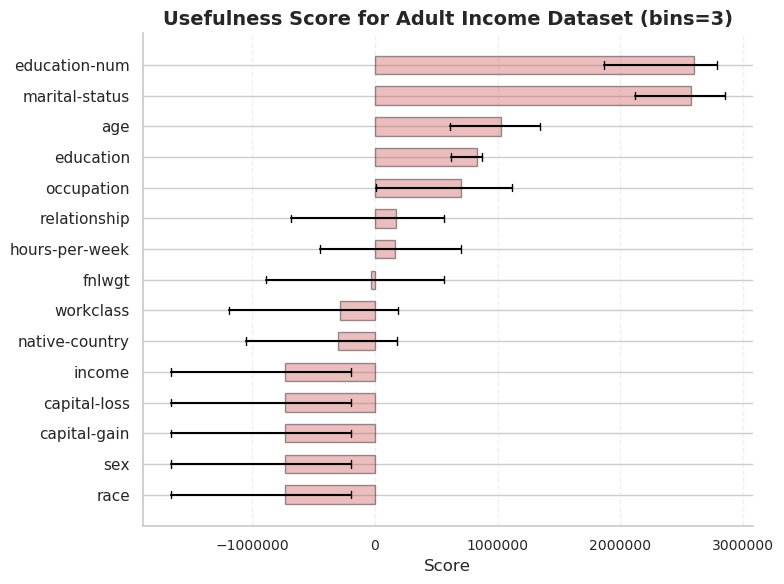

<Figure size 640x480 with 0 Axes>

In [66]:
random.seed(42)

bins = 3
tries = 20

_, _, features = train_tree_for_Adult_Income(2, 42, 3, 42)

scores = {feature: [] for feature in features}
accuracies = []

for i in range(tries):
    random_value = random.randint(0, 100000)
    clf, accuracy, features = train_tree_for_Adult_Income(10, random_value, bins, random_value, 100*bins)
    
    domains = {feature: (0, bins-1) for feature in features}
    tree = dec_tree_to_my_tree(clf, domains, features)
    
    for feature in features:
        scores[feature].append(compute_score(tree, feature, len(features), domains))
    accuracies.append(accuracy)
    print(i)

stats = []
for k, v in scores.items():
    q1 = np.percentile(v, 25)
    med = np.median(v)
    q3 = np.percentile(v, 75)
    stats.append((k, q1, med, q3))

# Sort by median
stats.sort(key=lambda x: x[2])
stats = stats[-15:]
labels, q1s, meds, q3s = zip(*stats)
y_pos = np.arange(len(labels))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Main horizontal bars at median
ax.barh(y_pos, meds, color='IndianRed', alpha=0.4, edgecolor='black', height=0.6)

bar_height = 0.6
line_height = bar_height * 0.4  # 40% of full bar height
for y, q1, q3 in zip(y_pos, q1s, q3s):
    # Short horizontal line for Q1–Q3
    ax.plot([q1, q3], [y, y], color='black', linewidth=1.5)

    # Small vertical ticks at Q1 and Q3
    ax.plot([q1, q1], [y - line_height / 2, y + line_height / 2], color='black', linewidth=1)
    ax.plot([q3, q3], [y - line_height / 2, y + line_height / 2], color='black', linewidth=1)

# Style
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Score', fontsize=12)
ax.set_title(f'Usefulness Score for Adult Income Dataset (bins={bins})', fontsize=14, weight='semibold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', labelsize=10)

print(np.mean(accuracies))

plt.tight_layout()
plt.show()
plt.savefig(f'adult_income_bins_{bins}.svg')

### Tests

In [142]:
# Mini test of counting
false = Node("False", 0, None, None)
true = Node("True", 1, None, None)
x1 = Node("x", 1.5, deepcopy(true), deepcopy(false))
x2 = Node("x", 0.5, deepcopy(true), x1)
y = Node("y", 0.5, deepcopy(false), deepcopy(true))
z = Node("z", 0.5, x2, y)

domains = {}
domains["x"] = (0, 2)
domains["y"] = (0, 1)
domains["z"] = (0, 1)

tree = Tree(z, domains)

tree.domains
tree.count()

print(f'Correct answer is 7, output was {tree.count()}')

# Minitest of negation
tree_to_negate = deepcopy(tree)
acum = tree_to_negate.count()
print(f'Correct answer is 7, output was {tree.count()}')

tree_to_negate.negate()
acum += tree_to_negate.count()

print(f'Correct answer is 12, output was {acum}')

# Minitest of conjunction
same_tree = deepcopy(tree)
same_tree_2 = deepcopy(tree)
same_tree_3 = deepcopy(tree)
opposite_tree = deepcopy(tree)

same_tree_3.conjunction(same_tree)
print(f'Correct answer is 7, output was {tree.count()}')

opposite_tree.negate()
same_tree_2.conjunction(opposite_tree)
print(f'Correct answer is 0, output was {same_tree_2.count()}')

# Minitest of conditioning
tree_to_condition = deepcopy(tree)
tree_to_condition.condition("z", 0)
print(f'Correct answer is 8, output was {tree_to_condition.count()}')

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("z", 1)
print(f'Correct answer is 6, output was {tree_to_condition.count()}')

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("x", 1)
print(f'Correct answer is 9, output was {tree_to_condition.count()}')

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("x", 1)
tree_to_condition.condition("y", 1)
print(f'Correct answer is 12, output was {tree_to_condition.count()}')

Correct answer is 7, output was 7
Correct answer is 7, output was 7
Correct answer is 12, output was 12
Correct answer is 7, output was 7
Correct answer is 0, output was 0
Correct answer is 8, output was 8
Correct answer is 6, output was 6
Correct answer is 9, output was 9
Correct answer is 12, output was 12


### TODO:
* Automatizar generar varios modelos con distintos hiperparametros y distintos sets de entrenamientos (2 horas)
* Agregar otro dataset (2 horas)
* Plottear todo (2 horas)